## Stein MH

In [1]:

import jax
import jax.numpy as jnp
from jax import vmap, jit
from functools import partial
import time

# -----------------------------------
# Utilities
# -----------------------------------

@jit
def rbf_kernel(X, Y, lengthscale=1.0):
    """
    Scalar RBF kernel matrix K(X,Y).
    X: (n, d), Y: (m, d) -> (n, m)
    """
    X = jnp.atleast_2d(X)
    Y = jnp.atleast_2d(Y)
    X2 = jnp.sum(X * X, axis=-1, keepdims=True)
    Y2 = jnp.sum(Y * Y, axis=-1, keepdims=True).T
    sqdist = X2 + Y2 - 2.0 * (X @ Y.T)
    return jnp.exp(-0.5 * sqdist / (lengthscale ** 2))


@jit
def gaussian_logpdf(x, mean, cov_chol):
    """
    Log N(x | mean, Sigma) with Sigma = cov_chol @ cov_chol.T
    """
    x = jnp.asarray(x)
    mean = jnp.asarray(mean)
    z = jax.scipy.linalg.solve_triangular(cov_chol, x - mean, lower=True)
    d = x.shape[-1]
    logdet = jnp.sum(jnp.log(jnp.diag(cov_chol)))
    return -0.5 * (d * jnp.log(2.0 * jnp.pi) + 2.0 * logdet + jnp.dot(z, z))


@jit
def gaussian_sample(key, mean, cov_chol):
    """Sample from N(mean, Sigma) with Sigma = cov_chol @ cov_chol.T"""
    z = jax.random.normal(key, shape=mean.shape)
    return mean + cov_chol @ z


# -----------------------------------
# Target distribution
# -----------------------------------

@jit
def logpi_gaussian_mixture(x):
    """Unnormalised log-density of a 2D Gaussian mixture."""
    means = jnp.array([[+2.0, +2.0],
                       [-2.0, +2.0],
                       [+2.0, -2.0],
                       [-2.0, -2.0]])
    cov = jnp.eye(2) * (0.6 ** 2)
    cov_chol = jnp.linalg.cholesky(cov)

    def one_comp_logpdf(m):
        return gaussian_logpdf(x, m, cov_chol)

    logws = vmap(one_comp_logpdf)(means)
    return jax.scipy.special.logsumexp(logws) - jnp.log(4.0)


# -----------------------------------
# Random-walk Gaussian proposal (for compatibility)
# -----------------------------------

class RWGaussian:
    def __init__(self, step: float, d: int):
        self.Sigma = jnp.eye(d) * (step ** 2)
        self.Sigma_chol = jnp.linalg.cholesky(self.Sigma)
        self.d = d

    def sampler(self, key, x):
        y = gaussian_sample(key, x, self.Sigma_chol)
        aux = {"mean": x, "Sigma_chol": self.Sigma_chol}
        return y, aux

    def logpdf(self, y, x, aux):
        return gaussian_logpdf(y, x, aux["Sigma_chol"])


# -----------------------------------
# Vanilla MH (optimized)
# -----------------------------------

def run_vanilla_mh(key, x0, n_steps, logpi, step=0.5):
    """
    Vanilla MH with symmetric RW proposal.
    Optimized using jax.lax.fori_loop for better performance.
    """
    d = x0.shape[-1]
    sigma_chol = jnp.eye(d) * step
    
    # Pre-allocate arrays
    xs = jnp.zeros((n_steps, d))
    accs = jnp.zeros(n_steps, dtype=bool)
    
    # Generate all random keys upfront
    keys = jax.random.split(key, n_steps)
    
    # JIT-compiled step function
    @jit
    def mh_step(x, key_t):
        key_prop, key_u = jax.random.split(key_t)
        y = gaussian_sample(key_prop, x, sigma_chol)
        log_alpha = logpi(y) - logpi(x)
        u = jnp.log(jax.random.uniform(key_u))
        accept = u < log_alpha
        x_new = jnp.where(accept, y, x)
        return x_new, accept
    
    # Run the chain
    x = x0
    for i in range(n_steps):
        x, acc = mh_step(x, keys[i])
        xs = xs.at[i].set(x)
        accs = accs.at[i].set(acc)
    
    acc_rate = jnp.mean(accs.astype(jnp.float32))
    return xs, acc_rate


# -----------------------------------
# Optimized KSD functions
# -----------------------------------

def create_ksd_functions(logpi, sigma_chol, kernel_lengthscale, eps=1e-2):
    """
    Create JIT-compiled KSD functions for a specific problem.
    This avoids issues with passing functions through JIT.
    """
    
    @jit
    def P_one_step(key, x):
        """π-reversible base kernel P one step"""
        key_prop, key_u = jax.random.split(key)
        y = gaussian_sample(key_prop, x, sigma_chol)
        log_alpha = logpi(y) - logpi(x)
        u = jnp.log(jax.random.uniform(key_u))
        accept = u < log_alpha
        return jnp.where(accept, y, x)
    
    @jit
    def ksd_witness_scalar(key, Z_eval, X_particles):
        """Compute KSD witness function at Z_eval given particles X_particles."""
        n = X_particles.shape[0]
        keys = jax.random.split(key, n)
        
        Ys = vmap(P_one_step)(keys, X_particles)
        K_ZY = rbf_kernel(Z_eval, Ys, kernel_lengthscale)
        K_ZX = rbf_kernel(Z_eval, X_particles, kernel_lengthscale)
        g_vals = jnp.mean(K_ZY - K_ZX, axis=1)
        return g_vals
    
    @jit
    def finite_diff_vector_witness(key, x, X_particles):
        """Build vector witness at x via finite-differences."""
        d = x.shape[-1]
        e = jnp.eye(d) * eps
        Z = jnp.concatenate([x[None, :], x[None, :] + e, x[None, :] - e], axis=0)
        gZ = ksd_witness_scalar(key, Z, X_particles)
        
        gp = gZ[1:1 + d]
        gm = gZ[1 + d:1 + 2 * d]
        grad = (gp - gm) / (2.0 * eps)
        return grad
    
    return P_one_step, ksd_witness_scalar, finite_diff_vector_witness


def run_ksd_enhanced_mh_optimized(
    key, x0, n_steps, logpi,
    step=0.5, eta=0.4, kernel_lengthscale=1.0,
    cloud_size=100, eps=1e-2
):
    """
    Optimized KSD-enhanced MH.
    Uses pre-compiled functions and efficient array operations.
    """
    d = x0.shape[-1]
    sigma_chol = jnp.eye(d) * step
    
    # Create JIT-compiled KSD functions
    _, _, finite_diff_vector_witness = create_ksd_functions(
        logpi, sigma_chol, kernel_lengthscale, eps
    )
    
    # Pre-allocate arrays
    xs = jnp.zeros((n_steps, d))
    accs = jnp.zeros(n_steps, dtype=bool)
    cloud = jnp.tile(x0[None, :], (cloud_size, 1))
    
    # Generate all random keys upfront
    keys = jax.random.split(key, n_steps)
    
    @jit
    def ksd_mh_step(x, cloud, cloud_idx, key_t):
        """Single KSD-enhanced MH step"""
        keys = jax.random.split(key_t, 5)
        
        # Update cloud
        cloud = cloud.at[cloud_idx % cloud_size].set(x)
        
        # Compute witness-based mean shifts
        mean_shift_x = eta * finite_diff_vector_witness(keys[0], x, cloud)
        mean_x = x + mean_shift_x
        y = gaussian_sample(keys[1], mean_x, sigma_chol)
        
        # Compute mean shift at y for reverse proposal
        mean_shift_y = eta * finite_diff_vector_witness(keys[2], y, cloud)
        mean_y = y + mean_shift_y
        
        # MH accept/reject
        log_q_y_given_x = gaussian_logpdf(y, mean_x, sigma_chol)
        log_q_x_given_y = gaussian_logpdf(x, mean_y, sigma_chol)
        
        log_alpha = (logpi(y) - logpi(x)) + (log_q_x_given_y - log_q_y_given_x)
        accept = jnp.log(jax.random.uniform(keys[3])) < log_alpha
        x_new = jnp.where(accept, y, x)
        
        return x_new, accept, cloud
    
    # Run the chain
    x = x0
    cloud_idx = 0
    
    for i in range(n_steps):
        x, acc, cloud = ksd_mh_step(x, cloud, cloud_idx, keys[i])
        xs = xs.at[i].set(x)
        accs = accs.at[i].set(acc)
        cloud_idx += 1
    
    acc_rate = jnp.mean(accs.astype(jnp.float32))
    return xs, acc_rate


# -----------------------------------
# Vectorized batch version for better performance
# -----------------------------------

def run_ksd_enhanced_mh_vectorized(
    key, x0, n_steps, logpi,
    step=0.5, eta=0.4, kernel_lengthscale=1.0,
    cloud_size=100, eps=1e-2, batch_size=100
):
    """
    Vectorized KSD-enhanced MH that processes multiple steps in batches.
    This can be significantly faster for long chains.
    """
    d = x0.shape[-1]
    sigma_chol = jnp.eye(d) * step
    n_batches = (n_steps + batch_size - 1) // batch_size
    
    # Create JIT-compiled KSD functions
    _, _, finite_diff_vector_witness = create_ksd_functions(
        logpi, sigma_chol, kernel_lengthscale, eps
    )
    
    @jit
    def process_batch(x_init, cloud, cloud_idx, keys_batch):
        """Process a batch of KSD-MH steps"""
        actual_batch_size = keys_batch.shape[0]
        xs_batch = jnp.zeros((actual_batch_size, d))
        accs_batch = jnp.zeros(actual_batch_size, dtype=bool)
        
        x = x_init
        for i in range(actual_batch_size):
            keys = jax.random.split(keys_batch[i], 5)
            
            # Update cloud
            cloud = cloud.at[(cloud_idx + i) % cloud_size].set(x)
            
            # Compute witness-based mean shifts
            mean_shift_x = eta * finite_diff_vector_witness(keys[0], x, cloud)
            mean_x = x + mean_shift_x
            y = gaussian_sample(keys[1], mean_x, sigma_chol)
            
            # Compute mean shift at y
            mean_shift_y = eta * finite_diff_vector_witness(keys[2], y, cloud)
            mean_y = y + mean_shift_y
            
            # MH accept/reject
            log_q_y_given_x = gaussian_logpdf(y, mean_x, sigma_chol)
            log_q_x_given_y = gaussian_logpdf(x, mean_y, sigma_chol)
            
            log_alpha = (logpi(y) - logpi(x)) + (log_q_x_given_y - log_q_y_given_x)
            accept = jnp.log(jax.random.uniform(keys[3])) < log_alpha
            x = jnp.where(accept, y, x)
            
            xs_batch = xs_batch.at[i].set(x)
            accs_batch = accs_batch.at[i].set(accept)
        
        return x, xs_batch, accs_batch, cloud
    
    # Initialize
    cloud = jnp.tile(x0[None, :], (cloud_size, 1))
    keys = jax.random.split(key, n_steps)
    
    # Process batches
    all_xs = []
    all_accs = []
    x = x0
    cloud_idx = 0
    
    for batch_idx in range(n_batches):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, n_steps)
        keys_batch = keys[start_idx:end_idx]
        
        x, xs_batch, accs_batch, cloud = process_batch(x, cloud, cloud_idx, keys_batch)
        all_xs.append(xs_batch)
        all_accs.append(accs_batch)
        cloud_idx = (cloud_idx + len(keys_batch)) % cloud_size
    
    xs = jnp.concatenate(all_xs)[:n_steps]
    accs = jnp.concatenate(all_accs)[:n_steps]
    acc_rate = jnp.mean(accs.astype(jnp.float32))
    return xs, acc_rate


# -----------------------------------
# Wrapper for backward compatibility
# -----------------------------------

def run_ksd_enhanced_mh(
    key, x0, n_steps, logpi,
    step=0.5, eta=0.4, kernel_lengthscale=1.0,
    burn_in_for_witness=50, cloud_max=None
):
    """Wrapper that maintains compatibility with original interface"""
    if cloud_max is None:
        cloud_max = max(burn_in_for_witness, 100)
    
    return run_ksd_enhanced_mh_optimized(
        key, x0, n_steps, logpi,
        step=step, eta=eta, kernel_lengthscale=kernel_lengthscale,
        cloud_size=cloud_max
    )



In [8]:
key = jax.random.PRNGKey(0)
d = 2
x0 = jnp.zeros((d,))
n_steps = 8000
step = 0.6
eta = 0.4
ls = 1.0  # kernel lengthscale

# Warm-up jit
_ = gaussian_sample(key, x0, jnp.eye(d) * step)

t0 = time.time()
xs_van, acc_van = run_vanilla_mh(key, x0, n_steps, logpi_gaussian_mixture, step=step)
t1 = time.time()

key2 = jax.random.PRNGKey(1)
t2 = time.time()
xs_ksd, acc_ksd = run_ksd_enhanced_mh_optimized(key2, x0, n_steps, logpi_gaussian_mixture,
                                      step=step, eta=eta, kernel_lengthscale=ls,
                                    cloud_size=32)
t3 = time.time()


print("Vanilla MH acceptance:", float(acc_van), "time (s):", round(t1 - t0, 3))
print("KSD–enhanced MH acceptance:", float(acc_ksd), "time (s):", round(t3 - t2, 3))

# -----------------------------------
# Plots (no seaborn; one chart per figure)
# -----------------------------------

# Scatter of samples (last 4000 steps)
tail = 4000
xs_v_tail = jnp.asarray(xs_van[-tail:])
xs_k_tail = jnp.asarray(xs_ksd[-tail:])



Vanilla MH acceptance: 0.5636250376701355 time (s): 2.932
KSD–enhanced MH acceptance: 0.5635000467300415 time (s): 3.524


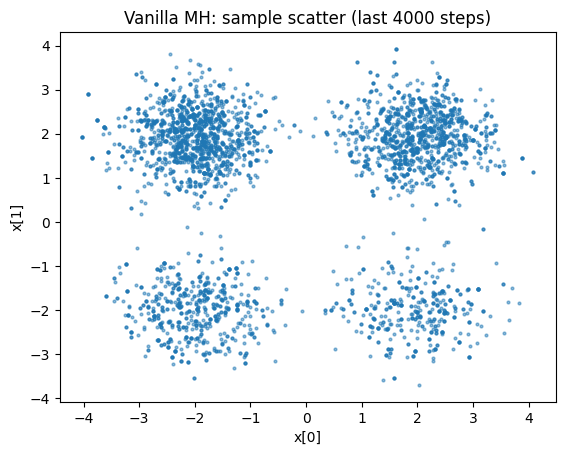

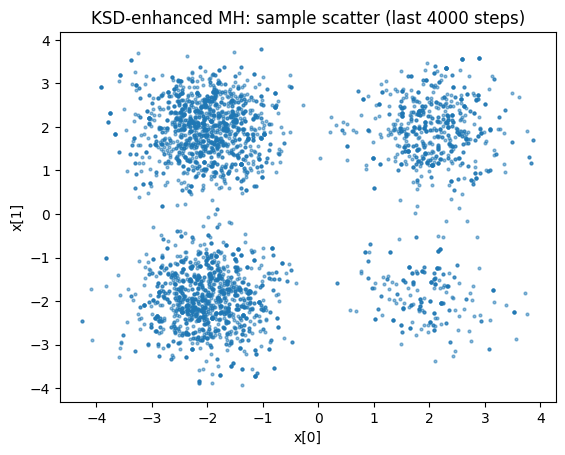

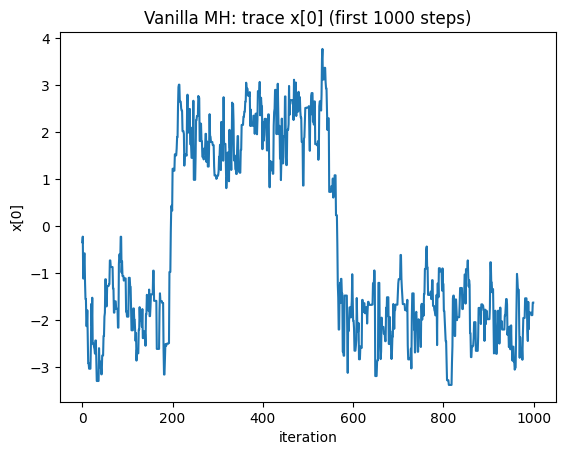

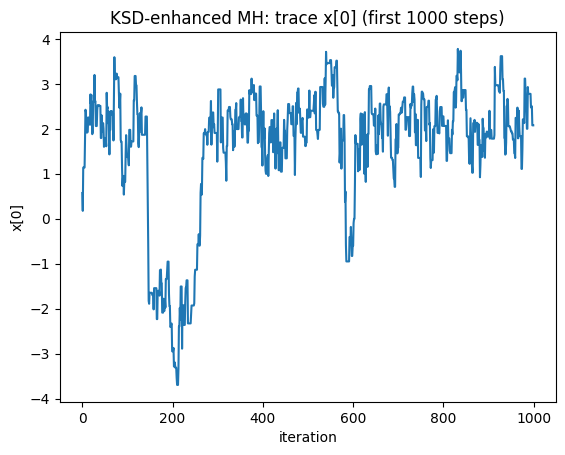

In [7]:
from matplotlib import pyplot as plt

fig1 = plt.figure()
plt.scatter(xs_v_tail[:,0], xs_v_tail[:,1], s=4, alpha=0.5)
plt.title("Vanilla MH: sample scatter (last {} steps)".format(tail))
plt.xlabel("x[0]")
plt.ylabel("x[1]")
plt.show()

fig2 = plt.figure()
plt.scatter(xs_k_tail[:,0], xs_k_tail[:,1], s=4, alpha=0.5)
plt.title("KSD-enhanced MH: sample scatter (last {} steps)".format(tail))
plt.xlabel("x[0]")
plt.ylabel("x[1]")
plt.show()

# Trace of first coordinate (first 1000 steps) to visualise mixing speed
trace_n = 1000
fig3 = plt.figure()
plt.plot(jnp.asarray(xs_van[:trace_n, 0]))
plt.title("Vanilla MH: trace x[0] (first {} steps)".format(trace_n))
plt.xlabel("iteration")
plt.ylabel("x[0]")
plt.show()

fig4 = plt.figure()
plt.plot(jnp.asarray(xs_ksd[:trace_n, 0]))
plt.title("KSD-enhanced MH: trace x[0] (first {} steps)".format(trace_n))
plt.xlabel("iteration")
plt.ylabel("x[0]")
plt.show()

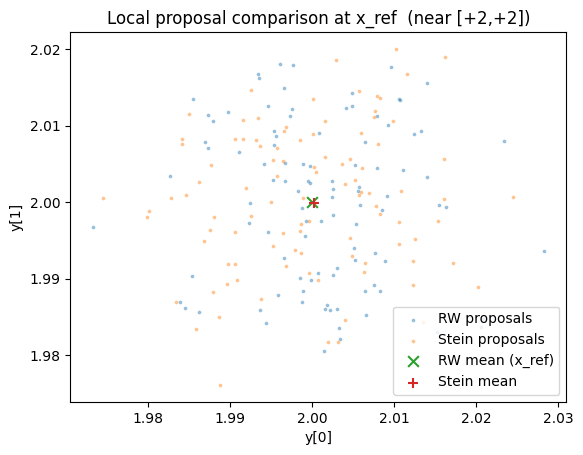

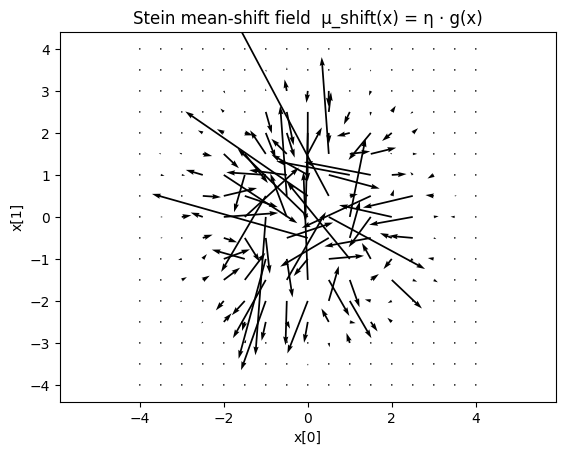

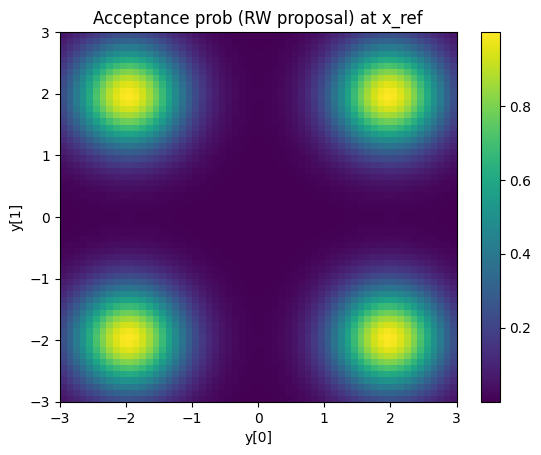

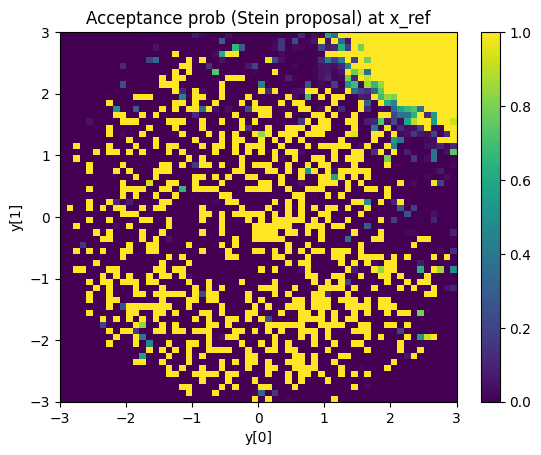

In [16]:
# -----------------------------------
# Visualising proposal differences
# -----------------------------------
import matplotlib.pyplot as plt

def build_ksd_tools(logpi, step, kernel_lengthscale=1.0, eps=1e-2, d=2):
    Sigma_chol = jnp.eye(d) * step  # Cholesky of Sigma = step^2 I
    P_one_step, ksd_witness_scalar, finite_diff_vector_witness = create_ksd_functions(
        logpi, Sigma_chol, kernel_lengthscale, eps
    )
    return Sigma_chol, finite_diff_vector_witness

def mean_shift_at(key, x, cloud, finite_diff_vector_witness, eta):
    g = finite_diff_vector_witness(key, x, cloud)
    return eta * g

def acceptance_surface_at_xref(x_ref, cloud, Sigma_chol, finite_diff_vector_witness, eta,
                               logpi, xlim=(-3,3), ylim=(-3,3), n=60, key=jax.random.PRNGKey(0)):
    """
    Compare acceptance prob surfaces for RW vs Stein proposals at a fixed x_ref.
    """
    import matplotlib.pyplot as plt
    Sig = Sigma_chol @ Sigma_chol.T

    xs = jnp.linspace(xlim[0], xlim[1], n)
    ys = jnp.linspace(ylim[0], ylim[1], n)

    # Mean for RW and Stein
    mu_rw = x_ref
    mu_shift = eta * finite_diff_vector_witness(key, x_ref, cloud)
    mu_st = x_ref + mu_shift

    Z_rw = jnp.zeros((n, n))
    Z_st = jnp.zeros((n, n))

    for i in range(n):
        for j in range(n):
            y = jnp.array([xs[i], ys[j]])

            # RW (symmetric): log q terms cancel
            log_alpha_rw = logpi(y) - logpi(x_ref)
            Z_rw = Z_rw.at[i, j].set(jnp.minimum(1.0, jnp.exp(log_alpha_rw)))

            # Stein (asymmetric): need q(y|x) and q(x|y)
            # q(y|x): N(mu_st, Sigma); q(x|y): N(y + eta*g(y), Sigma)
            log_q_y_given_x = gaussian_logpdf(y, mu_st, Sigma_chol)

            mu_shift_y = eta * finite_diff_vector_witness(jax.random.fold_in(key, i*n + j), y, cloud)
            mu_rev = y + mu_shift_y
            log_q_x_given_y = gaussian_logpdf(x_ref, mu_rev, Sigma_chol)

            log_alpha_st = (logpi(y) - logpi(x_ref)) + (log_q_x_given_y - log_q_y_given_x)
            Z_st = Z_st.at[i, j].set(jnp.minimum(1.0, jnp.exp(log_alpha_st)))

    # Plots (one chart per figure)
    plt.figure()
    plt.imshow(jnp.asarray(Z_rw), extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
               origin='lower', aspect='auto')
    plt.title("Acceptance prob (RW proposal) at x_ref")
    plt.xlabel("y[0]"); plt.ylabel("y[1]")
    plt.colorbar(); plt.show()

    plt.figure()
    plt.imshow(jnp.asarray(Z_st), extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
               origin='lower', aspect='auto')
    plt.title("Acceptance prob (Stein proposal) at x_ref")
    plt.xlabel("y[0]"); plt.ylabel("y[1]")
    plt.colorbar(); plt.show()


def draw_local_proposal_comparison(
    key, x_ref, cloud, Sigma_chol, finite_diff_vector_witness, eta,
    n_samp=1000, title_suffix=""
):
    """
    Compare samples from:
      - RW:   q_rw(y|x_ref) = N(x_ref, Sigma)
      - Stein q_st(y|x_ref) = N(x_ref + eta*g(x_ref), Sigma)
    """
    key, k1, k2, k3 = jax.random.split(key, 4)
    # Compute Stein shift at x_ref
    mu_shift = mean_shift_at(k1, x_ref, cloud, finite_diff_vector_witness, eta)
    mean_rw = x_ref
    mean_st = x_ref + mu_shift

    # Sample
    ys_rw = jnp.stack([gaussian_sample(jax.random.fold_in(k2, i), mean_rw, Sigma_chol) for i in range(n_samp)])
    ys_st = jnp.stack([gaussian_sample(jax.random.fold_in(k3, i), mean_st, Sigma_chol) for i in range(n_samp)])

    # Plot
    plt.figure()
    plt.scatter(ys_rw[:,0], ys_rw[:,1], s=3, alpha=0.35, label="RW proposals")
    plt.scatter(ys_st[:,0], ys_st[:,1], s=3, alpha=0.35, label="Stein proposals")
    plt.scatter(mean_rw[0], mean_rw[1], marker="x", s=60, label="RW mean (x_ref)")
    plt.scatter(mean_st[0], mean_st[1], marker="+", s=60, label="Stein mean")
    plt.title(f"Local proposal comparison at x_ref {title_suffix}")
    plt.xlabel("y[0]"); plt.ylabel("y[1]")
    plt.legend()
    plt.show()

def quiver_mean_shift_field(
    key, cloud, Sigma_chol, finite_diff_vector_witness, eta,
    xlim=(-4,4), ylim=(-4,4), grid_n=15
):
    xs = jnp.linspace(xlim[0], xlim[1], grid_n)
    ys = jnp.linspace(ylim[0], ylim[1], grid_n)
    X, Y = jnp.meshgrid(xs, ys, indexing="xy")
    U = jnp.zeros_like(X); V = jnp.zeros_like(Y)

    # small loop (keeps it simple and explicit)
    for i in range(grid_n):
        for j in range(grid_n):
            xpt = jnp.array([X[i,j], Y[i,j]])
            k_ij = jax.random.fold_in(key, i*1000 + j)
            shift = mean_shift_at(k_ij, xpt, cloud, finite_diff_vector_witness, eta)
            U = U.at[i,j].set(shift[0]); V = V.at[i,j].set(shift[1])

    plt.figure()
    plt.quiver(X, Y, U, V, angles='xy', scale_units='xy')
    plt.title("Stein mean-shift field  μ_shift(x) = η · g(x)")
    plt.xlabel("x[0]"); plt.ylabel("x[1]")
    plt.axis("equal")
    plt.show()


# ---------------------------
# Example: build a cloud, then visualise
# ---------------------------
key_vis = jax.random.PRNGKey(123)
d = 2
x0 = jnp.zeros((d,))
step = 0.01
eta = 10.
kernel_lengthscale = 1.
eps = 1e-2

# Build tools
Sigma_chol, finite_diff_vector_witness = build_ksd_tools(
    logpi=logpi_gaussian_mixture, step=step,
    kernel_lengthscale=kernel_lengthscale, eps=eps, d=d
)

# If you already ran a chain, reuse the last N points; else make a quick warmup:
N_cloud = 300
xs_warm, _ = run_ksd_enhanced_mh(
    key_vis, x0, n_steps=N_cloud, logpi=logpi_gaussian_mixture,
    step=step, eta=eta, kernel_lengthscale=kernel_lengthscale,
    burn_in_for_witness=50, cloud_max=200
)
cloud = xs_warm  # shape (N_cloud, 2)

# 1) Local proposal comparison at a chosen reference point
x_ref = jnp.array([2., 2.0])  # pick near a mode (adjust if you like)
draw_local_proposal_comparison(
    key_vis, x_ref, cloud, Sigma_chol, finite_diff_vector_witness, eta,
    n_samp=100, title_suffix=" (near [+2,+2])"
)

# 2) Mean-shift vector field over a grid
quiver_mean_shift_field(
    key_vis, cloud, Sigma_chol, finite_diff_vector_witness, eta,
    xlim=(-4,4), ylim=(-4,4), grid_n=17
)


# def acceptance_surface_at_xref(x_ref, cloud, Sigma_chol, finite_diff_vector_witness, eta,
#                                logpi, xlim=(-3,3), ylim=(-3,3), n=60, key=jax.random.PRNGKey(0)):


acceptance_surface_at_xref(
    x_ref, cloud, Sigma_chol, finite_diff_vector_witness, eta,
    logpi=logpi_gaussian_mixture,)